# Implementing optimisation algorithms to optimise parameters of linear functions
> Some description.

- toc: true 
- badges: true
- comments: true
- categories: [machine-learning, deep-learning]
- author: Augustas Macijauskas
- image: images/fastai_logo.png
- hide: true
- search_exclude: true

# Useful code bits

## Hiding/showing stuff

```
#hide
#hide_input
#collapse-hide
#collapse-show
#collapse-output
```

## Images

Use `![](my_icons/fastai_logo.png)` for local images and `![](https://image.flaticon.com/icons/svg/36/36686.svg)` for remote images

You can include captions with markdown images like this:

```
![](https://www.fast.ai/images/fastai_paper/show_batch.png "Credit: https://www.fast.ai/2020/02/13/fastai-A-Layered-API-for-Deep-Learning/")
```

## GitHub Flavored Emojis

Typing `I give this post two :+1:!` will render this:

I give this post two :+1:!

## Youtube Videos

Typing `> youtube: https://youtu.be/XfoYk_Z5AkI` will render this:


> youtube: https://youtu.be/XfoYk_Z5AkI

## Boxes / Callouts 

Typing `> Warning: There will be no second warning!` will render this:


> Warning: There will be no second warning!



Typing `> Important: Pay attention! It's important.` will render this:

> Important: Pay attention! It's important.



Typing `> Tip: This is my tip.` will render this:

> Tip: This is my tip.



Typing `> Note: Take note of this.` will render this:

> Note: Take note of this.



Typing `> Note: A doc link to [an example website: fast.ai](https://www.fast.ai/) should also work fine.` will render in the docs:

> Note: A doc link to [an example website: fast.ai](https://www.fast.ai/) should also work fine.

## Footnotes

You can have footnotes in notebooks, however the syntax is different compared to markdown documents. [This guide provides more detail about this syntax](https://github.com/fastai/fastpages/blob/master/_fastpages_docs/NOTEBOOK_FOOTNOTES.md), which looks like this:

```
{% raw %}For example, here is a footnote {% fn 1 %}.
And another {% fn 2 %}
{{ 'This is the footnote.' | fndetail: 1 }}
{{ 'This is the other footnote. You can even have a [link](www.github.com)!' | fndetail: 2 }}{% endraw %}
```

For example, here is a footnote {% fn 1 %}.

And another {% fn 2 %}

{{ 'This is the footnote.' | fndetail: 1 }}
{{ 'This is the other footnote. You can even have a [link](www.github.com)!' | fndetail: 2 }}

# TLDR

Some TLDR

# Introduction

Introducing the problem

# Imports

Toggle cells below if you want to see what imports are being made.

In [1]:
#hide
# Uncomment these and run once if you are using colab
# !pip install -qq torchtext==0.8.1
# !pip install -Uqq fastbook

In [2]:
#hide
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [3]:
#collapse-hide
import numpy as np
import matplotlib.pyplot as plt

# Data

In [4]:
# Create x
np.random.seed(0)
x = np.random.uniform(0, 100, size=100)
# x

In [5]:
slope = -2
intercept = 10
y = slope * x + intercept
# y

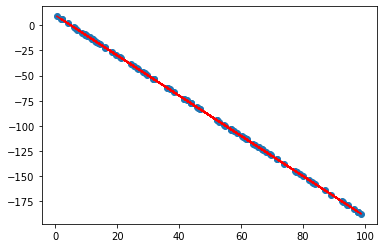

In [6]:
plt.scatter(x, y)
plt.plot(x, slope * x + intercept, color="red");

# Experiment

In [7]:
from collections import defaultdict

class Tracker:
    def __init__(self):
        self.tracker = defaultdict(list)
    
    def add_record(self, key, value):
        self.tracker[key].append(value)
    
    def get_values(self, key):
        if not key in self.tracker: raise KeyError(f"Key {key} not in tracker")

        return self.tracker[key]

In [8]:
def train_one_epoch(model, data, tracker, lr=1e-4):
    for x, y in data:
        y_pred = model.forward(x)
        error = 0.5 * (y_pred - y) ** 2
        grad_slope = x * (y_pred - y)
        grad_intercept = (y_pred - y)
        model.backward(grad_slope, grad_intercept, lr)
    tracker.add_record("error", error)

In [9]:
def perform_experiment(model, data, tracker, lr=1e-6, desired_error=1e-8):
    num_steps = 0
    while True:
        train_one_epoch(model, data, tracker, lr)
        num_steps += 100
        
        if tracker.get_values("error")[-1] <= desired_error:
            break

    return num_steps // 100, num_steps, model.slope, model.intercept

# Model with plain SGD

In [10]:
class LinearModelWithSGD:
    def __init__(self, initial_slope=1, initial_intercept=1):
        self.slope = initial_slope
        self.intercept = initial_intercept
    
    def forward(self, x):
        return self.slope * x + self.intercept
    
    def backward(self, grad_slope, grad_intercept, lr=1e-4):
        self.slope -= lr * grad_slope
        self.intercept -= lr * grad_intercept

(407857, 40785700, -1.999997792779954, 9.999857542522035)

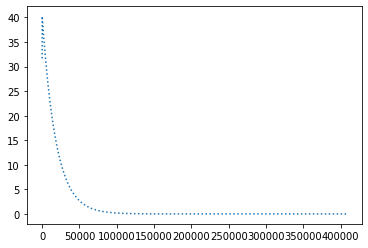

In [11]:
model = LinearModelWithSGD()
data = list(zip(x, y))
tracker = Tracker()
display(perform_experiment(model, data, tracker, lr=1e-6))
plt.plot(tracker.get_values("error"), linestyle="dotted");

# Model with SGD with momentum

In [12]:
class LinearModelWithSGDWithMomentum:
    def __init__(self, initial_slope=1, initial_intercept=1):
        self.slope = initial_slope
        self.intercept = initial_intercept

        self.slope_momentum = self.intercept_momentum = 0
    
    def forward(self, x):
        return self.slope * x + self.intercept
    
    def backward(self, grad_slope, grad_intercept, lr=1e-4, miu=0.99):
        self.slope_momentum = miu * self.slope_momentum - lr * grad_slope
        self.slope += self.slope_momentum

        self.intercept_momentum = miu * self.intercept_momentum - lr * grad_intercept
        self.intercept += self.intercept_momentum

(3866, 386600, -1.9999972688977041, 9.999857555245528)

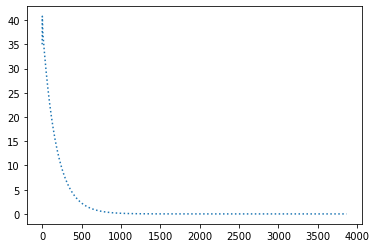

In [13]:
model = LinearModelWithSGDWithMomentum()
data = list(zip(x, y))
tracker = Tracker()
display(perform_experiment(model, data, tracker, lr=1e-6))
plt.plot(tracker.get_values("error"), linestyle="dotted");

# Conclusion

Put a conclusion here